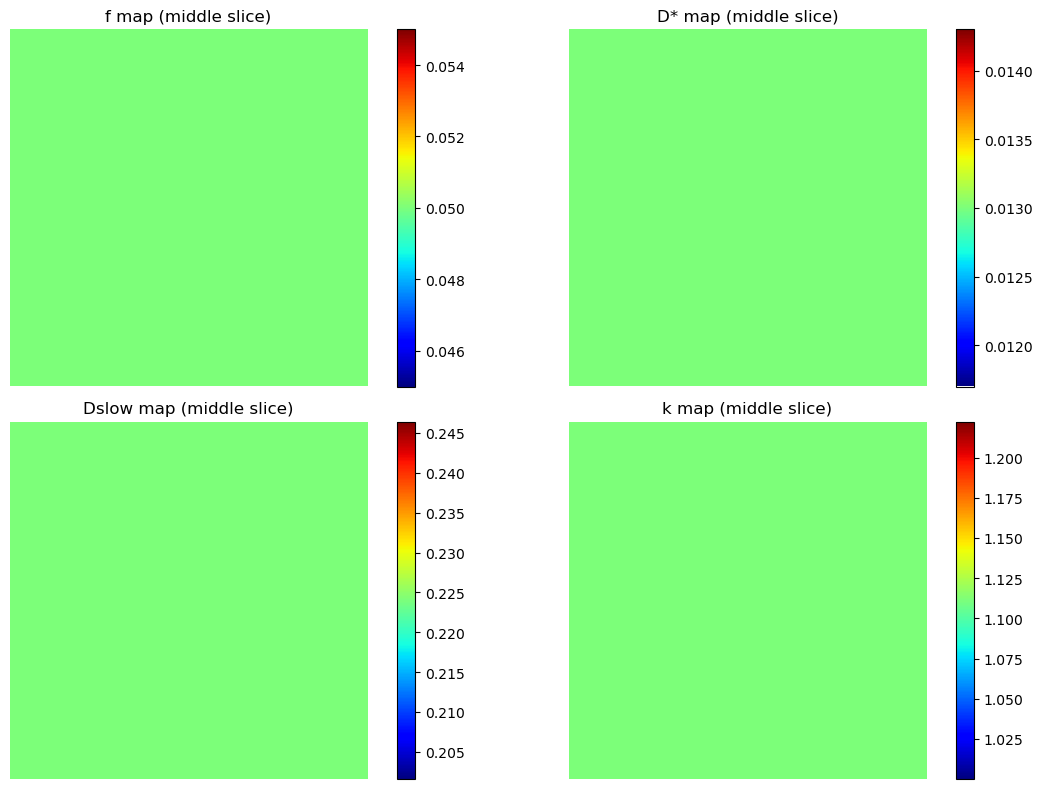

In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Load your saved maps
f_map = nib.load("fitted_f_map.nii.gz").get_fdata()
Dstar_map = nib.load("fitted_Dstar_map.nii.gz").get_fdata()
Dslow_map = nib.load("fitted_Dslow_map.nii.gz").get_fdata()
k_map = nib.load("fitted_k_map.nii.gz").get_fdata()

# Choose a middle slice
mid_slice = f_map.shape[2] // 2

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(f_map[:, :, mid_slice], cmap='jet')
plt.title('f map (middle slice)')
plt.axis('off')
plt.colorbar()

plt.subplot(2, 2, 2)
plt.imshow(Dstar_map[:, :, mid_slice], cmap='jet')
plt.title('D* map (middle slice)')
plt.axis('off')
plt.colorbar()

plt.subplot(2, 2, 3)
plt.imshow(Dslow_map[:, :, mid_slice], cmap='jet')
plt.title('Dslow map (middle slice)')
plt.axis('off')
plt.colorbar()

plt.subplot(2, 2, 4)
plt.imshow(k_map[:, :, mid_slice], cmap='jet')
plt.title('k map (middle slice)')
plt.axis('off')
plt.colorbar()

plt.tight_layout()
plt.show()

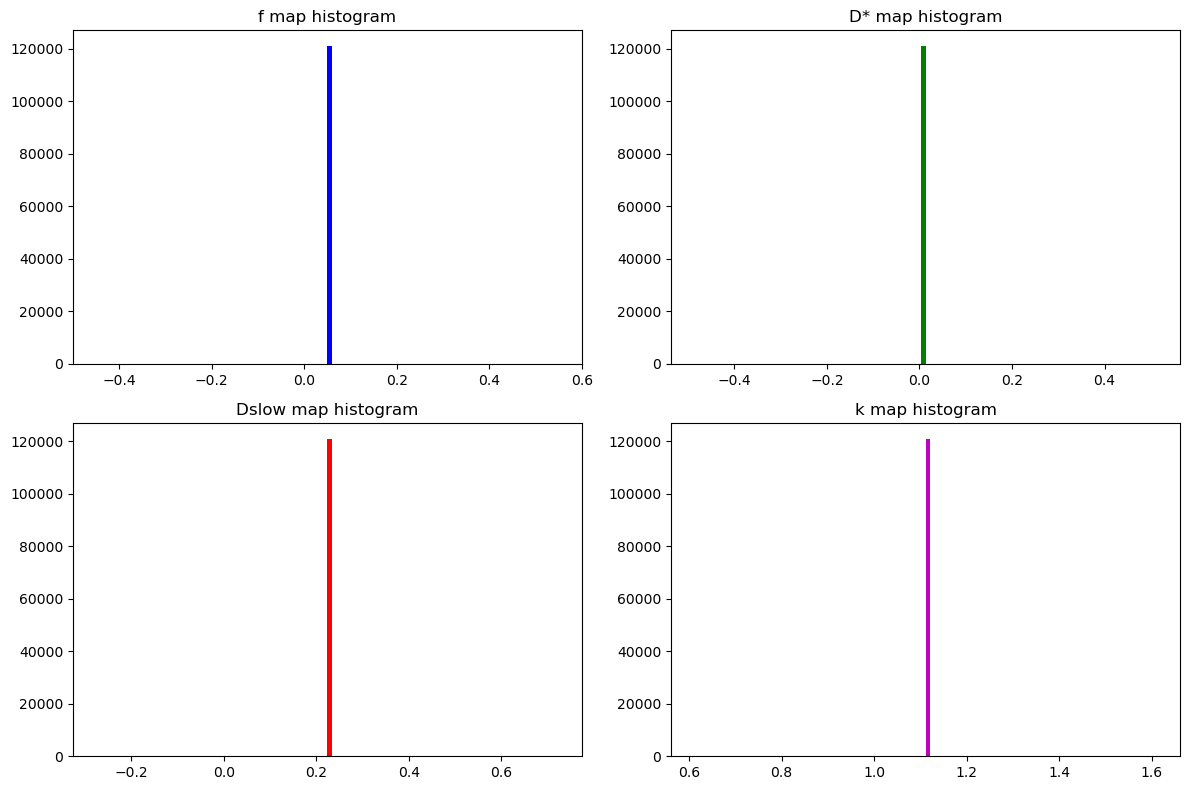

In [2]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(f_map.flatten()[~np.isnan(f_map.flatten())], bins=100, color='b')
plt.title('f map histogram')

plt.subplot(2, 2, 2)
plt.hist(Dstar_map.flatten()[~np.isnan(Dstar_map.flatten())], bins=100, color='g')
plt.title('D* map histogram')

plt.subplot(2, 2, 3)
plt.hist(Dslow_map.flatten()[~np.isnan(Dslow_map.flatten())], bins=100, color='r')
plt.title('Dslow map histogram')

plt.subplot(2, 2, 4)
plt.hist(k_map.flatten()[~np.isnan(k_map.flatten())], bins=100, color='m')
plt.title('k map histogram')

plt.tight_layout()
plt.show()

In [3]:
def show_slices(img, title):
    for i in range(img.shape[2]):
        plt.imshow(img[:, :, i], cmap='jet')
        plt.title(f"{title} - slice {i}")
        plt.axis('off')
        plt.colorbar()
        plt.show()
        input("Press Enter for next slice...")

# Example usage:
# show_slices(f_map, "f map")

In [7]:
print("f map: min", np.nanmin(f_map), "max", np.nanmax(f_map), "mean", np.nanmean(f_map))
print("Dstar map: min", np.nanmin(Dstar_map), "max", np.nanmax(Dstar_map), "mean", np.nanmean(Dstar_map))
print("Dslow map: min", np.nanmin(Dslow_map), "max", np.nanmax(Dslow_map), "mean", np.nanmean(Dslow_map))
print("k map: min", np.nanmin(k_map), "max", np.nanmax(k_map), "mean", np.nanmean(k_map))

f map: min 0.04999999999918969 max 0.04999999999918969 mean 0.04999999999918969
Dstar map: min 0.012999999999999998 max 0.012999999999999998 mean 0.013000000000000005
Dslow map: min 0.2239940129079918 max 0.2239940129079918 mean 0.2239940129079918
k map: min 1.111146405837161 max 1.111146405837161 mean 1.111146405837161


In [5]:
print("Non-nan voxels in f_map:", np.sum(~np.isnan(f_map)))

Non-nan voxels in f_map: 121000


In [6]:
print("Signal min:", np.min(data))
print("Signal max:", np.max(data))
print("Signal shape:", data.shape)

NameError: name 'data' is not defined

In [8]:
import numpy as np
import nibabel as nb
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

#Function for IVIMDKI Hybrid
def ivim_dki_model(b, f, D_star, D_slow, k):
    exp1 = np.exp(np.clip(-b * D_star, -100, 100))
    exp2 = np.exp(np.clip(-b * D_slow + (1/6) * (b ** 2) * (D_slow ** 2) * k, -100, 100))
    return f * exp1 + (1 - f) * exp2

#Loading MrI fILE
snr60="/Users/ayush/Desktop/project-internsip/new_work/OneDrive_2_23-05-2025/Simulation-III_Nifty-data/Simulation-III_SNR60/Data-1_Simulation-III_SNR-60.nii"
snr60_data=nb.load(snr60)

# --- Fitting settings ---
bvals = np.array([0, 25, 50, 75, 100, 150, 200, 500, 800, 1000, 1250, 1500, 2000])
bounds = ([0.0001, 0.0001, 0.001, 0.01], [0.05, 0.5, 1, 3])
p0 = [0.013, 0.013, 0.23, 1.1]

# Output arrays
data=snr60_data.get_fdata()
print(data[0,0,0,:])
print(data[10,10,0,:])
print(data[50,50,5,:])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.99452148 0.96671924 0.9041447  0.86668907 0.84315996 0.80714502
 0.76572044 0.53808596 0.42170732 0.33309872 0.2897614  0.30572569
 0.22742491]
